
![ARM Aerosol Observing SYstem](https://armgov.svcs.arm.gov/uploads/AOS-scaled-e1753992753919.jpeg "ARM AOS")


<img src="images/arm_logo.png" width=250 alt="Project Pythia Logo"></img>

# AOS and miniAOS bias characterization - number concentration

---

                                                                       
# U.S. DOE ARM Aerosol Observing System (AOS)                              
                                                                          
The Aerosol Observing System (AOS) is a standardized suite of surface-based,
in situ instruments operated by the U.S. Department of Energy's            
https://www.arm.gov. It serves as ARM's primary platform for characterizing 
atmospheric aerosols and trace gases at Earth's surface. The five ARM AOS   
installations collectively represent the most comprehensive field-deployable
aerosol measurement network in the United States.                          

## Purpose and Scientific Goals

The AOS is designed to quantify how airborne particles interact with solar
radiation and influence Earth's energy balance — a major source of
uncertainty in energy forecasting. Its three core research objectives are:

1. Long-term trend monitoring — tracking changes in aerosol optical and
physical properties over time.
2. Process understanding — examining the atmospheric mechanisms governing
aerosol lifecycles and aerosol–cloud interactions.
3. Model development and validation — generating benchmark datasets for
atmospheric models.

## Measurement Categories

The AOS addresses seven measurement classes:

| Category | Examples |
|---|---|                                                                   
| Number concentration | Total particle counts |
| Size distribution | Sub- and super-micron size spectra |
| Chemical composition | Aerosol mass, organic/inorganic speciation |
| Optical properties | Scattering, absorption, backscatter|
| Hygroscopicity | Aerosol water uptake and hygroscopic growth factor |
| Trace gases | Ozone (O₃), Nitrates ($NO_{x}$), Sulfates ($SO_{x}$) |
| Supporting meteorology | Temperature, RH, pressure at the inlet |

These measurements enable derivation of radiative forcing parameters
including single-scattering albedo, the asymmetry parameter, and mass
scattering efficiency.

## Key Instruments

Each AOS site deploys a tailored complement of up to 24 instruments. Core
components common to most sites include:

- Nephelometer (single- and three-wavelength) — total and hemispheric
aerosol light scattering
- Condensation Particle Counter (CPC) — total particle number concentration
- Particle Soot Absorption Photometer (PSAP) / Aethalometer — aerosol light
absorption
- Optical Particle Counter (OPC) — size-resolved number concentration
- Aerosol Chemical Speciation Monitor (ACSM) — near-real-time non-refractory
aerosol composition
- Single Particle Soot Photometer (SP2) — refractory black carbon mass
- Cloud Condensation Nuclei (CCN) counter — CCN activity at multiple
supersaturations
- Ozone monitor — surface O₃ concentration

Instrument selection varies by site to account for local environment and
scientific priorities. The Southern Great Plains (SGP) site carries the most
extensive suite; mobile deployments are configured for portability.

## Deployment Sites

The AOS is deployed at ARM's fixed atmospheric observatories and mobile
facilities:

- Southern Great Plains (SGP) — Lamont, Oklahoma (continental, agricultural)
- North Slope of Alaska (NSA) — Utqiaġvik (Arctic)
- Eastern North Atlantic (ENA) — Graciosa Island, Azores (remote marine)
- ARM Mobile Facilities (AMF1, AMF2) — short-term deployments worldwide to
targeted research locations, including BNF

# Mini-AOS

The AOS system is quite large, requiring two seatainers to host the entire suite of instruments. This makes agile deployment of the system difficult due to both its large size and large power consumption. Therefore, a miniaturized suite, the miniAOS, includes a subset of instruments designed to measure aerosol size distributions that is more portable and less power hungry than the AOS. This improves ARM's capability to deploy on towers, difficult terrain, and tight spaces. However, the reliability of the miniAOS suite needs to be assessed, as the Bankhead National Forest (BNF) site is the first deployment of the miniAOS. Therefore, this notebook shows how ARM is assessing the reliability of the measurements by comparing the AOS-measured particle size distributions with those from the miniAOS at the M1 site. 

## Key Reference

Uin, J., et al. (2019). Atmospheric Radiation Measurement (ARM) Aerosol
Observing Systems (AOS) for Surface-Based In Situ Atmospheric Aerosol and
Trace Gas Measurements. Journal of Atmospheric and Oceanic Technology,
36(12).
https://journals.ametsoc.org/view/journals/atot/36/12/jtech-d-19-0077.1.xml

---
Sources:
- https://www.arm.gov/capabilities/instruments/aos
- https://www.arm.gov/instruments/aos
-
https://journals.ametsoc.org/view/journals/atot/36/12/jtech-d-19-0077.1.xml



## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [ACT Documentation](https://arm-doe.github.io/ACT/index.html) | Necessary | Used for reading ARM NetCDF files |
| [Xarray](https://docs.xarray.dev/en/stable/) | Necessary | Dataset loading, alignment, and time selection |
| [Dask Distributed](https://distributed.dask.org/en/stable/) | Helpful | Parallel file loading via `client.map` |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf.html) | Helpful | Familiarity with ARM data structure and metadata |
| [Aerosol Measurements: Principles, Techniques, and Applications](https://content.e-bookshelf.de/media/reading/L-587858-f097d0697a.pdf) | Helpful | Background on aerosol sizing techniques |

---

## Imports

In [1]:
import act
import matplotlib.pyplot as plt
import os
import numpy as np                                                          
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import pandas as pd
from scipy import stats
from glob import glob

from sklearn.linear_model import LinearRegression
from distributed import Client, LocalCluster, progress
%matplotlib inline

## Load the AOS and miniAOS Data

Here we load four instrument datastreams from the Bankhead National Forest (BNF) AMF3 site:

- **AOS SMPS** (`bnfaossmpsM1.b1`) — Scanning Mobility Particle Sizer; reference mobility size distribution
- **AOS APS** (`bnfaosapsM1.b1`) — Aerodynamic Particle Sizer; reference aerodynamic size distribution
- **miniAOS mSEMS** (`bnfminiaosmsemsM1.a1`) — miniaturized SEMS; mobility size distribution
- **miniAOS OPC** (`bnfminiaosopcM1.b1`) — Optical Particle Counter; optical size distribution

Data are downloaded from [ARM Data Discovery](https://adc.arm.gov/discovery/). You will need an ARM account — replace `os.environ["ARM_USERNAME"]` and `os.environ["ARM_PASSWORD"]` with your credentials, or set those environment variables before running this notebook.

In [23]:
act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
                                'bnfaossmpsM1.b1', '2025-11-01',
                                '2026-04-30')

[DOWNLOADING] bnfaossmpsM1.b1.20260429.000459.nc

If you use these data to prepare a publication, please cite:

Singh, A., Kuang, C., Howie, J., Salwen, C., & Hayes, C. Scanning mobility
particle sizer (AOSSMPS), 2026-04-29 to 2026-04-30, Bankhead National Forest,
AL, USA; Long-term Mobile Facility (BNF), Bankhead National Forest, AL, AMF3
(Main Site) (M1). Atmospheric Radiation Measurement (ARM) User Facility.
https://doi.org/10.5439/1476898



['/Users/rjackson/bnf-aos-bias-characterization/notebooks/bnfaossmpsM1.b1/bnfaossmpsM1.b1.20260429.000459.nc']

In [24]:
act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
                                'bnfaosapsM1.b1', '2025-11-01',
                                '2026-04-30')

[DOWNLOADING] bnfaosapsM1.b1.20260429.000000.nc

If you use these data to prepare a publication, please cite:

Singh, A., Oliveira, D., Koontz, A., Sedlacek, A., & Kuang, C. Aerodynamic
Particle Sizer (AOSAPS), 2026-04-29 to 2026-04-30, Bankhead National Forest, AL,
USA; Long-term Mobile Facility (BNF), Bankhead National Forest, AL, AMF3 (Main
Site) (M1). Atmospheric Radiation Measurement (ARM) User Facility.
https://doi.org/10.5439/1407135



['/Users/rjackson/bnf-aos-bias-characterization/notebooks/bnfaosapsM1.b1/bnfaosapsM1.b1.20260429.000000.nc']

In [25]:
act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
                                'bnfminiaosmsemsM1.a1', '2025-11-01',
                                '2026-04-30')

No files returned or url status error.
Check datastream name, start, and end date. 



[]

In [26]:
act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
                                'bnfminiaosopcM1.b1', '2025-11-01',
                                '2026-04-30')

[DOWNLOADING] bnfminiaosopcM1.b1.20260429.000002.nc

If you use these data to prepare a publication, please cite:

Singh, A., Campos, D., & Subba, T. Optical Particle Counter (MINIAOSOPC),
2026-04-29 to 2026-04-30, Bankhead National Forest, AL, USA; Long-term Mobile
Facility (BNF), Bankhead National Forest, AL, AMF3 (Main Site) (M1). Atmospheric
Radiation Measurement (ARM) User Facility.



['/Users/rjackson/bnf-aos-bias-characterization/notebooks/bnfminiaosopcM1.b1/bnfminiaosopcM1.b1.20260429.000002.nc']

In [ ]:
act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
                                'bnfminiaosopcM1.b1', '2025-11-01',
                                '2026-04-30')

In [ ]:
act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
                                'bnfmetM1.b1', '2025-11-01',
                                '2026-04-30')

In [ ]:
act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
                                'bnfaosmetM1.a1', '2025-11-01',
                                '2026-04-30')

In [2]:
# Start a local cluster of 4 workers to enable parallelism
client = Client(LocalCluster(n_workers=4, threads_per_worker=1))
client

/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 51883 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:51883/status,
Dashboard: http://127.0.0.1:51883/status,Workers: 4
Total threads: 4,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:51884,Workers: 0
Dashboard: http://127.0.0.1:51883/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:51899,Total threads: 1
Dashboard: http://127.0.0.1:51903/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:51888,


In [3]:
# Per-instrument config for hourly aggregation + flag thresholds.
# Detected from the input filename (substring match on the datastream tag).
_INSTRUMENT_CONFIG = {
    'aps': {
        'flow_var': 'total_flow_rate',
        'flow_nominal': None,                       # no spec → no flag
        'rh_var': None,                             # no sample_relative_humidity in file
        'rh_range': None,
        'box_temp_var': 'box_temperature',          # APS-only enclosure T
        'sample_temp_var': 'inlet_temperature',
        'status_vars': ['status_flags'],
        'conc_range': [0, 800]
    },
    'smps': {
        'flow_var': 'detector_sample_flow',
        'flow_nominal': 0.95,
        'rh_var': 'sample_relative_humidity',
        'rh_range': (-np.inf, 50.0),                # < 50 %
        'box_temp_var': None,
        'sample_temp_var': 'sample_temperature',
        'status_vars': ['classifier_status', 'detector_status',
                        'communication_status'],
        'conc_range': [100, 50000]
    },
    'msems': {
        'flow_var': 'mcpc_sample_flow',
        'flow_nominal': 0.340,
        'rh_var': 'sheath_relative_humidity_avg',   # proxy — no sample RH variable
        'rh_range': (-np.inf, 50.0),
        'box_temp_var': None,
        'sample_temp_var': 'sample_temperature_avg',
        'status_vars': ['mcpc_errors', 'msems_errors'],
        'conc_range': [100, 50000]
        
    },
    'opc': {
        'flow_var': 'flow_sensor',
        'flow_nominal': None,                       # no spec → no flag
        'rh_var': 'sample_relative_humidity',
        'rh_range': (-np.inf, 50.0),
        'box_temp_var': None,
        'sample_temp_var': 'sample_temperature',
        'status_vars': ['error_code'],
        'conc_range': [0, 800]
    },
}


def _detect_instrument(file):
    name = file.lower()
    # 'msems' before 'smps' so the substring match doesn't collide.
    for tag in ('msems', 'smps', 'aps', 'opc'):
        if tag in name:
            return tag
    raise ValueError(f"Could not infer instrument from filename: {file}")


def _safe_flag(condition, *inputs):
    valid = inputs[0].notnull()
    for inp in inputs[1:]:
        valid = valid & inp.notnull()
    return xr.where(valid, condition, False).astype(bool)


def get_hourly_averaged_variables(file):
    """Hourly-average AOS / miniAOS data and emit per-hour QC flags.

    Returns an xr.Dataset on a 1-h time axis containing total_N_conc,
    flow_rate, status (bitwise-OR of the instrument's status registers),
    the per-criterion flag_* booleans applicable to this instrument, and
    any_flag (logical OR of those). Run add_concentration_spike_flag() on
    the concatenated per-datastream Dataset to add the per-day spike flag.
    """
    cfg = _INSTRUMENT_CONFIG[_detect_instrument(file)]
    out = {}

    with act.io.read_arm_netcdf(file) as ds:
        out['total_N_conc'] = ds['total_N_conc'].resample(time='1h').mean().load()
        out['flow_rate']    = ds[cfg['flow_var']].resample(time='1h').mean().load()

        if cfg['rh_var'] and cfg['rh_var'] in ds.variables:
            out['sample_relative_humidity'] = (
                ds[cfg['rh_var']].resample(time='1h').mean().load()
            )
        if cfg['sample_temp_var'] and cfg['sample_temp_var'] in ds.variables:
            out['sample_temperature'] = (
                ds[cfg['sample_temp_var']].resample(time='1h').mean().load()
            )
        if cfg['box_temp_var'] and cfg['box_temp_var'] in ds.variables:
            out['box_temperature'] = (
                ds[cfg['box_temp_var']].resample(time='1h').mean().load()
            )

        # Hourly bitwise-OR of all status registers. The netCDFs store these
        # as float64, so cast to int64 first (NaN → 0).
        status_hourly = None
        for vname in cfg['status_vars']:
            if vname not in ds.variables:
                continue
            # Load to numpy first; np.bitwise_or.reduce is not dask-compatible.
            v_int = ds[vname].astype('int64').load()
            v_h = v_int.resample(time='1h').reduce(np.bitwise_or.reduce).astype('int64')
            status_hourly = v_h if status_hourly is None else (status_hourly | v_h)
        if status_hourly is None:
            status_hourly = xr.zeros_like(out['total_N_conc']).astype('int64')
        out['status'] = status_hourly

    flags = {}
    if cfg['flow_nominal'] is not None:
        nom = cfg['flow_nominal']
        flags['flag_flow'] = _safe_flag(
            (abs(out['flow_rate'] - nom) / nom) > 0.10, out['flow_rate']
        )
    if 'sample_relative_humidity' in out and cfg['rh_range'] is not None:
        lo, hi = cfg['rh_range']
        rh = out['sample_relative_humidity']
        flags['flag_rh'] = _safe_flag((rh < lo) | (rh > hi), rh)
    if 'box_temperature' in out:
        bt = out['box_temperature']
        flags['flag_temp'] = _safe_flag((bt < 17.0) | (bt > 35.0), bt)
    flags['flag_status'] = (out['status'] != 0)
    n = out['total_N_conc']
    flags['flag_conc_range'] = _safe_flag((n < cfg['conc_range'][0]) | (n > cfg['conc_range'][1]), n)

    any_flag = None
    for f in flags.values():
        any_flag = f if any_flag is None else (any_flag | f)
    flags['any_flag'] = any_flag

    out.update(flags)
    return xr.Dataset(out)


def add_concentration_spike_flag(ds, sigma=3.0):
    """Add flag_conc_spike (True where total_N_conc deviates > sigma * std
    from that calendar day's mean) and update any_flag. Run on the
    concatenated hourly Dataset for one datastream after xr.concat."""
    n = ds['total_N_conc']
    s = n.to_series()
    grp = s.groupby(s.index.floor('D'))
    day_mean = grp.transform('mean')
    day_std  = grp.transform('std')
    spike = (s - day_mean).abs() > sigma * day_std
    spike = spike.where(day_std > 0, False).fillna(False).astype(bool)
    spike_da = xr.DataArray(spike.values, dims='time', coords={'time': n['time']})
    ds = ds.assign(flag_conc_spike=spike_da)
    ds = ds.assign(any_flag=ds['any_flag'] | spike_da)
    return ds


def get_hourly_met_flags(file):
    """Hourly QC flags from the surface-met datastream (bnfmetM1.b1).

    Returns an xr.Dataset on a 1-h time axis with the driving aggregates and
    per-criterion booleans:
        rh_max       — hourly max of rh_mean (%)
        precip_rate  — hourly max of pwd_precip_rate_mean_1min (mm/hr)
        visibility   — hourly min of pwd_mean_vis_1min (m)
        flag_rh      — rh_max > 85
        flag_rain    — precip_rate > 0
        flag_fog     — visibility < 1000  (WMO fog definition)
        any_flag     — OR of the three flags
    """
    with act.io.read_arm_netcdf(file) as ds:
        rh_max      = ds['rh_mean'].resample(time='1h').max().load()
        precip_rate = ds['pwd_precip_rate_mean_1min'].resample(time='1h').max().load()
        visibility  = ds['pwd_mean_vis_1min'].resample(time='1h').min().load()

    flag_rh   = _safe_flag(rh_max > 85.0, rh_max)
    flag_rain = _safe_flag(precip_rate > 0.0, precip_rate)
    flag_fog  = _safe_flag(visibility < 1000.0, visibility)
    any_flag  = flag_rh | flag_rain | flag_fog

    return xr.Dataset({
        'rh_max':      rh_max,
        'precip_rate': precip_rate,
        'visibility':  visibility,
        'flag_rh':     flag_rh,
        'flag_rain':   flag_rain,
        'flag_fog':    flag_fog,
        'any_flag':    any_flag,
    })

def get_hourly_met_variables(file):
    """Hourly QC flags from the surface-met datastream (bnfmetM1.b1).

    Returns an xr.Dataset on a 1-h time axis with the hourly averaged
    temperature, relative humidity, and wind speed from the AOS met sensor.
    """
    with act.io.read_arm_netcdf(file) as ds:
        rh_mean      = ds['rh_ambient'].resample(time='1h').mean().load()
        precip_rate = ds['rain_intensity'].resample(time='1h').sum().load()/60
        temp = ds['temperature_ambient'].resample(time='1h').max().load()
        spd = ds['wind_speed'].resample(time='1h').mean().load()
        

    return xr.Dataset({
        'rh_mean':      rh_mean,
        'precip_accum': precip_rate,
        'temp_mean':    temp,
        'wind_speed': spd})
    

def compare_instrument_pair(ds_aos, ds_miniaos,
                            name_aos='aos', name_miniaos='miniaos'):
    """Pairwise hourly comparison flags between an AOS and a miniAOS Dataset.

    Both inputs must be hourly Datasets containing total_N_conc (the output of
    get_hourly_averaged_variables() after xr.concat across files for one
    datastream). Inputs are outer-joined on time so we can detect hours where
    one instrument is missing.

    Output (on the union time axis):
        n_<aos>, n_<miniaos>  — total_N_conc from each (NaN where missing)
        bias_pct              — (miniAOS - AOS) / AOS * 100  (NaN if AOS<=0
                                or either is missing)
        flag_zero             — either N < 5 cm^-3 (noise floor)
        flag_missing          — either is NaN at this hour
        flag_outlier          — |bias_pct - day_mean| > 3 * day_std, computed
                                per calendar day on hours that are neither
                                missing nor at the noise floor
        any_flag              — OR of the three flags
    """
    a, m = xr.align(ds_aos['total_N_conc'], ds_miniaos['total_N_conc'],
                    join='outer')

    flag_missing = (a.isnull() | m.isnull())
    flag_zero    = _safe_flag((a < 5) | (m < 5), a, m)

    safe_a = a.where((a > 0) & a.notnull() & m.notnull())
    bias_pct = (m - safe_a) / safe_a * 100.0

    # Per-day mean/std on "clean" hours only — including missing or noise-floor
    # hours would inflate the std and mask real outliers.
    clean = bias_pct.where(~(flag_zero | flag_missing))
    s = clean.to_series()
    grp = s.groupby(s.index.floor('D'))
    day_mean = grp.transform('mean')
    day_std  = grp.transform('std')
    outlier = (s - day_mean).abs() > 3 * day_std
    outlier = outlier.where(day_std > 0, False).fillna(False).astype(bool)
    flag_outlier = xr.DataArray(outlier.values, dims='time',
                                coords={'time': bias_pct['time']})

    any_flag = flag_missing | flag_zero | flag_outlier

    return xr.Dataset({
        f'n_{name_aos}':     a,
        f'n_{name_miniaos}': m,
        'bias_pct':     bias_pct,
        'flag_zero':    flag_zero,
        'flag_missing': flag_missing,
        'flag_outlier': flag_outlier,
        'any_flag':     any_flag,
    })


# View datasets

In [4]:
aossmps_dataset = xr.open_mfdataset('bnfaossmpsM1.b1/bnfaossmpsM1.b1.202512*.nc')
aossmps_dataset

/var/folders/f7/j8d4tzw924s73dlkdx4d4h_c0000gp/T/ipykernel_4746/4157806820.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  aossmps_dataset = xr.open_mfdataset('bnfaossmpsM1.b1/bnfaossmpsM1.b1.202512*.nc')


<xarray.Dataset> Size: 57MB
Dimensions:                                   (time: 8785, bound: 2,
                                               diameter_mobility: 192)
Coordinates:
  * time                                      (time) datetime64[ns] 70kB 2025...
  * diameter_mobility                         (diameter_mobility) float32 768B ...
Dimensions without coordinates: bound
Data variables: (12/75)
    base_time                                 (time) datetime64[ns] 70kB 2025...
    time_offset                               (time) datetime64[ns] 70kB dask.array<chunksize=(288,), meta=np.ndarray>
    time_bounds                               (time, bound) datetime64[ns] 141kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    diameter_mobility_bounds                  (time, diameter_mobility, bound) float32 13MB dask.array<chunksize=(288, 192, 2), meta=np.ndarray>
    lower_size                                (time) float32 35kB dask.array<chunksize=(288,), meta=np.ndarray>
    upper_size                                (time) float32 35kB dask.array<chunksize=(288,), meta=np.ndarray>
    ...                                        ...
    detector_status                           (time) float64 70kB dask.array<chunksize=(288,), meta=np.ndarray>
    neutralizer_status                        (time) float32 35kB dask.array<chunksize=(288,), meta=np.ndarray>
    communication_status                      (time) float64 70kB dask.array<chunksize=(288,), meta=np.ndarray>
    lat                                       (time) float32 35kB 34.34 ... 3...
    lon                                       (time) float32 35kB -87.34 ... ...
    alt                                       (time) float32 35kB 293.0 ... 2...
Attributes: (12/28)
    command_line:                 aossmpscorr -s bnf -f M1 --max-runtime 0
    Conventions:                  ARM-1.3
    process_version:              ingest-aossmpscorr-1.3-0.el9
    dod_version:                  aossmps-b1-3.0
    input_datastreams:            bnfaossmpsM1.a1 : 1.3 : 20251201.000458
    site_id:                      bnf
    ...                           ...
    wide_range_scan_mode:         On
    DMA_to_CPC_time_delay:        1.600000 s
    instrument_output_units:      dW/dlogDp
    instrument_output_weighting:  Number
    doi:                          10.5439/1476898
    history:                      created by user armflowprod on machine prod...

In [5]:
miniaosmsems_dataset = xr.open_mfdataset('bnfminiaosmsemsM1.a1/bnfminiaosmsemsM1.a1.202511*.nc')

/var/folders/f7/j8d4tzw924s73dlkdx4d4h_c0000gp/T/ipykernel_71196/3993241203.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  miniaosmsems_dataset = xr.open_mfdataset('bnfminiaosmsemsM1.a1/bnfminiaosmsemsM1.a1.202511*.nc')


In [7]:
aos_dataset = xr.open_dataset('bnfaosapsM1.b1/bnfaosapsM1.b1.20251101.000000.nc')
aos_dataset

<xarray.Dataset> Size: 50MB
Dimensions:                           (time: 86399, bound: 2,
                                       diameter_aerodynamic: 51)
Coordinates:
  * time                              (time) datetime64[ns] 691kB 2025-11-01T...
  * diameter_aerodynamic              (diameter_aerodynamic) float32 204B 0.5...
Dimensions without coordinates: bound
Data variables: (12/38)
    base_time                         datetime64[ns] 8B ...
    time_offset                       (time) datetime64[ns] 691kB ...
    time_bounds                       (time, bound) datetime64[ns] 1MB ...
    diameter_aerodynamic_bounds       (diameter_aerodynamic, bound) float32 408B ...
    dN_dlogDp                         (time, diameter_aerodynamic) float32 18MB ...
    qc_dN_dlogDp                      (time, diameter_aerodynamic) int32 18MB ...
    ...                                ...
    avalanche_photodiode_voltage      (time) float32 346kB ...
    sheath_pump_voltage               (time) float32 346kB ...
    status_flags                      (time) float64 691kB ...
    lat                               float32 4B ...
    lon                               float32 4B ...
    alt                               float32 4B ...
Attributes: (12/17)
    command_line:            aosapscorr -s bnf -f M1 --max-runtime 0
    Conventions:             ARM-1.3
    process_version:         ingest-aosapscorr-1.6-0.el9
    dod_version:             aosaps-b1-1.2
    input_datastreams:       bnfaosapsM1.a0 : 1.9 : 20251101.000000
    site_id:                 bnf
    ...                      ...
    Instrument_Description:  TSI APS 332100
    serial_number:           72332025
    configuration_file:      Used values from input file headers
    integration_interval:    1 s
    doi:                     10.5439/1407135
    history:                 created by user armflowprod on machine prod-slur...

In [8]:
smps_dataset = xr.open_mfdataset('bnfaossmpsM1.b1/*20260212*.nc')
smps_dataset

<xarray.Dataset> Size: 510kB
Dimensions:                                   (time: 288, bound: 2,
                                               diameter_mobility: 192)
Coordinates:
  * time                                      (time) datetime64[ns] 2kB 2026-...
  * diameter_mobility                         (diameter_mobility) float32 768B ...
Dimensions without coordinates: bound
Data variables: (12/75)
    base_time                                 datetime64[ns] 8B ...
    time_offset                               (time) datetime64[ns] 2kB dask.array<chunksize=(288,), meta=np.ndarray>
    time_bounds                               (time, bound) datetime64[ns] 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    diameter_mobility_bounds                  (diameter_mobility, bound) float32 2kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    lower_size                                (time) float32 1kB dask.array<chunksize=(288,), meta=np.ndarray>
    upper_size                                (time) float32 1kB dask.array<chunksize=(288,), meta=np.ndarray>
    ...                                        ...
    detector_status                           (time) float64 2kB dask.array<chunksize=(288,), meta=np.ndarray>
    neutralizer_status                        (time) float32 1kB dask.array<chunksize=(288,), meta=np.ndarray>
    communication_status                      (time) float64 2kB dask.array<chunksize=(288,), meta=np.ndarray>
    lat                                       float32 4B ...
    lon                                       float32 4B ...
    alt                                       float32 4B ...
Attributes: (12/28)
    command_line:                 aossmpscorr -s bnf -f M1 --max-runtime 86400
    Conventions:                  ARM-1.3
    process_version:              ingest-aossmpscorr-1.3-0.el9
    dod_version:                  aossmps-b1-3.0
    input_datastreams:            bnfaossmpsM1.a1 : 1.3 : 20260212.000458
    site_id:                      bnf
    ...                           ...
    wide_range_scan_mode:         On
    DMA_to_CPC_time_delay:        1.600000 s
    instrument_output_units:      dW/dlogDp
    instrument_output_weighting:  Number
    doi:                          10.5439/1476898
    history:                      created by user armflowprod on machine prod...

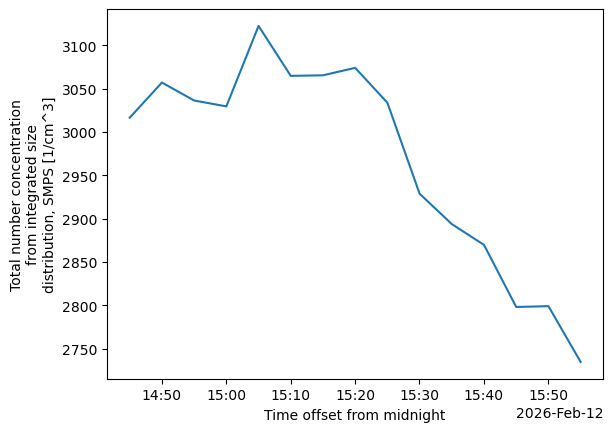

In [9]:
smps_dataset["total_N_conc"].sel(time=slice("2026-02-12T14:45:00", "2026-02-12T16:00:00")).plot()

In [5]:
miniaosopc_list = sorted(glob('bnfminiaosopcM1.b1/*.nc'))
futures = client.map(get_hourly_averaged_variables, miniaosopc_list)
progress(futures)
miniaosopc_N = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")

/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


In [6]:
aosaps_list = sorted(glob('bnfaosapsM1.b1/*.nc'))
futures = client.map(get_hourly_averaged_variables, aosaps_list)
progress(futures)
aosaps_N = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")

/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


The OPC and APS operate at different scan rates, so their native time coordinates do not align. We resample both to 1-minute means during file loading (see `get_N_conc` above), then use `xr.align` with an inner join to retain only the overlapping time period.

In [7]:
aosaps_total_N_resampled, miniaosopc_total_N_resampled = xr.align(aosaps_N, miniaosopc_N)     

In [8]:
miniaosopc_total_N_resampled

<xarray.Dataset> Size: 130kB
Dimensions:                   (time: 3621)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2025-11-15 ... 2026-...
Data variables:
    total_N_conc              (time) float32 14kB 101.2 116.9 ... 75.17 63.71
    flow_rate                 (time) float32 14kB nan nan nan ... nan nan nan
    sample_relative_humidity  (time) float32 14kB 20.07 20.01 ... 29.91 29.39
    sample_temperature        (time) float32 14kB 29.62 29.64 ... 29.44 29.49
    status                    (time) int64 29kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    flag_rh                   (time) bool 4kB False False False ... False False
    flag_status               (time) bool 4kB False False False ... False False
    flag_conc_range           (time) bool 4kB False False False ... False False
    any_flag                  (time) bool 4kB False False False ... False False

In [9]:
aps_opc_flags = compare_instrument_pair(aosaps_total_N_resampled,
                                        miniaosopc_total_N_resampled,
                                        "aps", "opc")

In [10]:
met_list = sorted(glob('bnfaosmetM1.a1/*.nc'))
futures = client.map(get_hourly_met_variables, met_list)
progress(futures)
met_vars = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")
met_vars = xr.align(met_vars, aps_opc_flags)

In [130]:
## Let's look at all of the flagged time periods

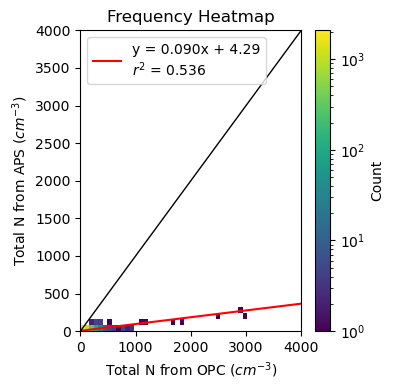

<Figure size 640x480 with 0 Axes>

In [11]:
def plot_linear_regression(x, y, ax=None, x_label="Total N from OPC", 
                           y_label="Total N from APS",
                           x_units="$cm^{-3}$", y_units="$cm^{-3}$",
                              title="Frequency Heatmap",
                             bins=50, cmap="viridis", log_norm=True,
                              colorbar_label="Count",
                             fit_color="red", fit_linewidth=1.5,
                              legend_loc="upper left",
                             xlim=(0, 3500), ylim=(0, 3500),
                             unity_line=True, unity_color="k",
                              unity_linewidth=1.0,
                             figsize=(4, 4), show=True):
      """
      Plot a 2D frequency heatmap of x vs. y with a linear best-fit line.

      Parameters
      ----------
      x : array-like
          Total particle number concentration from the probe on the x-axis.
      y : array-like
          Total particle number concentration from the probe on the y-axis.
      ax : matplotlib.axes.Axes, optional
          Axes object to plot on. If None, a new figure and axes are created.
      x_label : str, optional
          Label for the x-axis. Default is ``"Total N from OPC"``.
      y_label : str, optional
          Label for the y-axis. Default is ``"Total N from APS"``.
      x_units : str, optional
          Units appended to the x-axis label. Default is ``"$cm^{-3}$"``.
      y_units : str, optional
          Units appended to the y-axis label. Default is ``"$cm^{-3}$"``.
      title : str, optional
          Plot title. Default is ``"Frequency Heatmap"``.
      bins : int or [int, int], optional
          Number of bins for the 2D histogram. Default is 50.
      cmap : str, optional
          Colormap for the heatmap. Default is ``"viridis"``.
      log_norm : bool, optional
          If True, apply log normalization to the colorbar. Default is True.
      colorbar_label : str, optional
          Label for the colorbar. Default is ``"Count"``.
      fit_color : str, optional
          Color of the best-fit line. Default is ``"red"``.
      fit_linewidth : float, optional
          Line width of the best-fit line. Default is 1.5.
      legend_loc : str, optional
          Location of the legend. Default is ``"upper left"``.
      xlim : tuple of float, optional
          (min, max) limits for the x-axis. Default is ``(0, 3500)``.
      ylim : tuple of float, optional
          (min, max) limits for the y-axis. Default is ``(0, 3500)``.
      unity_line : bool, optional
          If True, draw the 1:1 line. Default is True.
      unity_color : str, optional
          Color of the 1:1 line. Default is ``"k"``.
      unity_linewidth : float, optional
          Line width of the 1:1 line. Default is 1.0.
      figsize : tuple of float, optional
          Figure size in inches. Used only when ax is None. Default is ``(4, 4)``.
      show : bool, optional
          If True, call plt.show() after plotting. Default is True.
      """
      mask = np.logical_and(np.isfinite(x), np.isfinite(y))
      slope, intercept, r, *_ = stats.linregress(x[mask], y[mask])

      if ax is None:
          fig, ax = plt.subplots(figsize=figsize)
      else:
          fig = ax.get_figure()

      norm = mcolors.LogNorm() if log_norm else None
      _, _, _, img = ax.hist2d(x, y, bins=np.linspace(0, xlim[1], bins), norm=norm, cmap=cmap)
      fig.colorbar(img, ax=ax, label=colorbar_label)

      x_fit = np.array(xlim)
      ax.plot(x_fit, slope * x_fit + intercept, color=fit_color,
              linewidth=fit_linewidth,
              label=f"y = {slope:.3f}x + {intercept:.2f}\n$r^2$ = {r**2:.3f}")

      if unity_line:
          ax.plot(xlim, ylim, color=unity_color, linewidth=unity_linewidth)

      ax.set_xlabel(f"{x_label} ({x_units})" if x_units else x_label)
      ax.set_ylabel(f"{y_label} ({y_units})" if y_units else y_label)
      ax.set_title(title)
      ax.set_xlim(xlim)
      ax.set_ylim(ylim)
      ax.legend(loc=legend_loc)

      plt.tight_layout()
      if show:
          plt.show()
    
plot_linear_regression(miniaosopc_total_N_resampled["total_N_conc"], 
                       aosaps_total_N_resampled["total_N_conc"], xlim=(0, 4000), ylim=(0, 4000))
plt.savefig('total_linear_fit_aps_opc.png', dpi=300, bbox_inches='tight')

## Filtering based off of DQRs

DQRs are not all approved yet, so we are using Google Sheets for now to updates.


In [12]:
sheet_id = "1k_Ipo74IjrVgR8llMwzn9BCO_OepsFUFkBKI4NZp0KU"
gid = 0
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
dqrs = pd.read_csv(url)
dqrs

,Instrument,St day/time,End day/time,DQR present,bobby to check
0,AOS SMPS,2026-01-15 8:30:00,2026-01-22 16:30:00,D260123.2,NaN
1,AOS SMPS,2026-02-15 16:45:00,2026-02-15 18:45:00,D260219.1,NaN
2,AOS SMPS,2026-02-13 17:50:00,2026-02-13 18:30:00,D260219.1,NaN
3,AOS SMPS,2026-02-12 16:50:00,2026-02-12 17:50:00,D260219.1,NaN
4,AOS SMPS & APS,2026-02-23 0:00,2026-02-26 23:59:59,D260303.14,NaN
...,...,...,...,...,...
59,miniAOS mSEMS and OPC,20260327 18:30,20260327 19:30,Just after to power outage. pump down,NaN
60,miniAOS OPC,20260401 17:30,20260401 21:30,sample line disrupted due to reinstallation of...,"OPC is about 1/6 of APS and well correlated, n..."
61,miniAOS mSEMS and OPC,20260408 19:30,20260408 21:00,sampling disrupted,NaN
62,miniAOS OPC,20260409 15:30,20260409 16:45,mSEMs and OPC zero,NaN


In [13]:
aps_mask = xr.ones_like(aosaps_total_N_resampled).astype(bool)
opc_mask = xr.ones_like(miniaosopc_total_N_resampled).astype(bool)
for i in range(len(dqrs)):
    instrument = dqrs["Instrument"].loc[i]
    start_time = dqrs["St day/time"].loc[i]
    end_time = dqrs["End day/time"].loc[i]

    if not isinstance(start_time, str):
        continue
    # Zero pad seconds if not available
    if not isinstance(start_time, str):
        continue
    start_date = start_time.split(" ")[0]
    if not "-" in start_date:
        start_date = start_date[:4] + "-" + start_date[4:6] + "-" + start_date[6:]
    start_time_hhmmss = start_time.split(" ")[1]
    if len(start_time_hhmmss.split(":")) == 2:
        start_time_hhmmss = start_time_hhmmss + ":00"
    
    start_time_hhmmss = ":".join(["%02d" % int(x) for x in start_time_hhmmss.split(":")])
    end_date = end_time.split(" ")[0]
    if not "-" in end_date:
        end_date = end_date[:4] + "-" + end_date[4:6] + "-" + end_date[6:]
    end_time_hhmmss = end_time.split(" ")[1]
    end_time_hhmmss = ":".join(["%02d" % int(x) for x in end_time_hhmmss.split(":")])
    if len(end_time_hhmmss.split(":")) == 2:
        end_time_hhmmss = end_time_hhmmss + ":00"

    if "aps" in instrument.lower():
        st = np.datetime64(start_date + "T" + start_time_hhmmss)
        ed = np.datetime64(end_date + "T" + end_time_hhmmss)
        aps_mask = xr.where(np.logical_and(aps_mask["time"] > st, aps_mask["time"] < ed), False, aps_mask)

    if "opc" in instrument.lower():
        st = np.datetime64(start_date + "T" + start_time_hhmmss)
        ed = np.datetime64(end_date + "T" + end_time_hhmmss)
        opc_mask = xr.where(np.logical_and(aps_mask["time"] > st, opc_mask["time"] < ed), False, opc_mask)

Now, we would like to see if there is any variance in the bias over time. This will help us figure out if there are any particularly problematic time periods to examine. First, we will plot the fits by month.

In [14]:
aosaps_total_N_resampled = aosaps_total_N_resampled.where(aps_mask)
miniaosopc_total_N_resampled = miniaosopc_total_N_resampled.where(opc_mask)

In [15]:
months = [11, 12, 1, 2, 3, 4]
time_strings = ["2024-11", "2024-12", "2025-01", "2025-02", "2025-03", "2025-04"]
slope = np.zeros(len(months))
intercept = np.zeros(len(months))
r = np.zeros(len(times))

for i, t in enumerate(months):
    x = aosaps_total_N_resampled.isel(time=aosaps_total_N_resampled.time.dt.month==t).values
    y = miniaosopc_total_N_resampled.isel(time=miniaosopc_total_N_resampled.time.dt.month==t).values
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    slope[i], intercept[i], r[i], *_ = stats.linregress(x, y)
    
times = np.array(time_strings, dtype="datetime64")
fig, ax = plt.subplots(3, 1, figsize=(6, 8))
ax[0].plot(times, slope)
ax[0].set_ylabel("Slope")
ax[1].plot(times, intercept)
ax[1].set_ylabel("Intercept")
ax[2].plot(times, r**2)
ax[2].set_ylabel("$R^{2}$")
ax[2].set_xlabel("Month [YY-MM]")
ax[0].set_title("Mean fits and intercepts by month for $N$ OPC vs $N$ APS")
fig.savefig('Mean_fits_and_intercepts_by_month.png')

NameError: name 'times' is not defined

From the above plot, it looks like the bias between the two instruments is the least during December and January. We see a significant degredation in the fit for April, while the high bias worsens in Feburary and March (with still a good fit). So, let's split the above scatter plots into four time periods: Nov, Dec-Jan, Feb-Mar, and April.

401 points in X, 401 points in Y between 2025-11-01 and 2025-12-01
1211 points in X, 1211 points in Y between 2025-12-01 and 2026-02-01
1115 points in X, 1115 points in Y between 2026-02-01 and 2026-04-01
476 points in X, 476 points in Y between 2026-04-01 and 2026-05-01


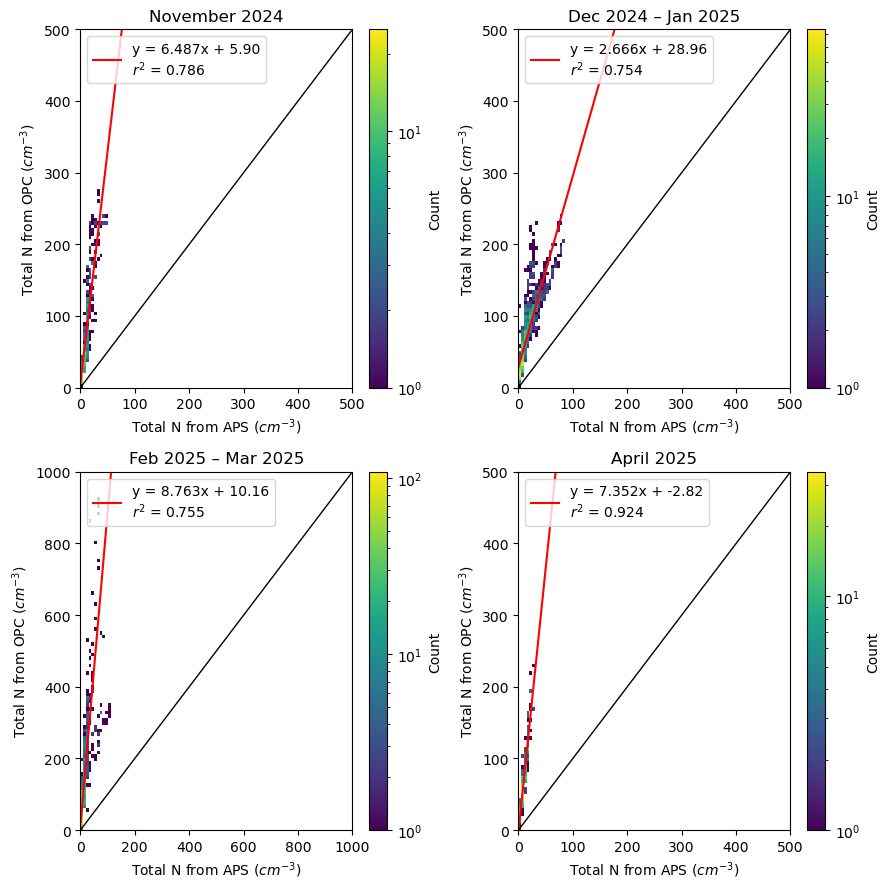

In [36]:
def plot_seasonal_panels(x, y, x_label="Total N from APS", y_label="Total N from OPC",       
                           x_units="$cm^{-3}$", y_units="$cm^{-3}$",
                           periods=None, ncols=2, **kwargs):
      """
      Plot frequency heatmaps of x vs. y separated into time period subpanels.

      Parameters
      ----------
      x : xarray.DataArray
          Total particle number concentration from the probe on the x-axis.
          Must have a datetime64 time coordinate.
      y : xarray.DataArray
          Total particle number concentration from the probe on the y-axis.
          Must have a datetime64 time coordinate.
      x_label : str, optional
          Label for the x-axis. Default is ``"Total N from OPC"``.
      y_label : str, optional
          Label for the y-axis. Default is ``"Total N from APS"``.
      x_units : str, optional
          Units appended to the x-axis label. Default is ``"$cm^{-3}$"``.
      y_units : str, optional
          Units appended to the y-axis label. Default is ``"$cm^{-3}$"``.
      periods : list of (str, str, str), optional
          List of (label, start, end) tuples defining each subpanel. start and
          end are date strings interpreted as a half-open interval [start, end).
          Defaults to four periods spanning November 2024 through April 2025.
      ncols : int, optional
          Number of columns in the subplot grid. Default is 2.
      **kwargs
          Additional keyword arguments passed to plot_linear_regression.
      """
      if periods is None:
          periods = [
              ("November 2024",       "2025-11-01", "2025-12-01"),
              ("Dec 2024 – Jan 2025", "2025-12-01", "2026-02-01"),
              ("Feb 2025 – Mar 2025", "2026-02-01", "2026-04-01"),
              ("April 2025",          "2026-04-01", "2026-05-01"),
          ]

      nrows = int(np.ceil(len(periods) / ncols))
      fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))

      for ax, (title, start, end) in zip(np.array(axes).flat, periods):
          x_sub = x.sel(time=slice(start, end)).values
          y_sub = y.sel(time=slice(start, end)).values
          valid = np.logical_and(np.isfinite(x_sub), np.isfinite(y_sub))
          x_sub, y_sub = x_sub[valid], y_sub[valid]
          Nx = len(x_sub)
          Ny = len(y_sub)
          
          print(f"{Nx} points in X, {Ny} points in Y between {start} and {end}")
          xlim = [0, np.max([np.ceil(np.nanpercentile(x_sub, 99) / 500) * 500, np.ceil(np.nanpercentile(y_sub, 99) / 500) * 500])]
          ylim = xlim
          plot_linear_regression(x_sub, y_sub, ax=ax, title=title,
                                 x_label=x_label, y_label=y_label,
                                 x_units=x_units, y_units=y_units,
                                 xlim=xlim, ylim=ylim,
                                 show=False, **kwargs)

      # Hide any unused axes
      for ax in np.array(axes).flat[len(periods):]:
          ax.set_visible(False)

      plt.tight_layout()
      plt.show()
      return fig
    
fig = plot_seasonal_panels(aosaps_total_N_resampled["total_N_conc"], 
                     miniaosopc_total_N_resampled["total_N_conc"], bins=100)
fig.savefig('scatter_plots_by_season.png', dpi=150, bbox_inches='tight')

---

## mSEMS vs. SMPS: Mobility-Based Number Concentration

The miniAOS **mSEMS** (miniaturized Scanning Electrical Mobility Spectrometer) is the miniAOS counterpart to the AOS **SMPS** (Scanning Mobility Particle Sizer). Unlike the OPC–APS pair above, both instruments size particles by electrical mobility using a differential mobility analyzer (DMA), so they sample the same physical quantity and we expect much closer agreement. Residual differences reflect calibration offsets, flow rate drift, or size range mismatches rather than differences in measurement principle.

The SMPS covers roughly 10–500 nm (electrical mobility diameter) and the mSEMS covers a similar range, making their integrated total $N$ directly comparable.

The seasonal panels above reveal how the OPC–APS relationship evolves across the deployment period. Periods with slopes near 1 and high $r^2$ indicate good agreement between the miniAOS OPC and the reference AOS APS. Deviations from the 1:1 line reflect systematic biases, which may stem from differences in sizing principle (optical vs. aerodynamic diameter), changes in aerosol composition, or instrument drift.

Unlike the OPC–APS pair, the mSEMS and SMPS both size particles by electrical mobility using a differential mobility analyzer (DMA). Because they use the same physical principle, we expect much closer agreement — deviations here more directly reflect instrument calibration differences or flow rate discrepancies rather than fundamental sizing method differences.

In [17]:
smps_list = sorted(glob('bnfaossmpsM1.b1/*.nc'))
futures = client.map(get_hourly_averaged_variables, smps_list)
progress(futures)
aossmps_N = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")

/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge

In [18]:
msems_list = sorted(glob('bnfminiaosmsemsM1.a1/*.nc'))
futures = client.map(get_hourly_averaged_variables, msems_list)
progress(futures)
miniaomsems_N = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")

/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


The SMPS and mSEMS operate at different scan periods. We apply the same 1-minute resampling (via `get_N_conc`) and inner-join alignment used for the OPC–APS pair above.

In [19]:
miniaomsems_total_N_resampled, aossmps_total_N_resampled = xr.align(miniaomsems_N, aossmps_N)

In [20]:
smps_mask = xr.ones_like(miniaomsems_total_N_resampled).astype(bool)
msems_mask = xr.ones_like(aossmps_total_N_resampled).astype(bool)
for i in range(len(dqrs)):
    instrument = dqrs["Instrument"].loc[i]
    start_time = dqrs["St day/time"].loc[i]
    end_time = dqrs["End day/time"].loc[i]
    
    # Zero pad seconds if not available
    if not isinstance(start_time, str):
        continue
    start_date = start_time.split(" ")[0]
    if not "-" in start_date:
        start_date = start_date[:4] + "-" + start_date[4:6] + "-" + start_date[6:]
    start_time_hhmmss = start_time.split(" ")[1]
    if len(start_time_hhmmss.split(":")) == 2:
        start_time_hhmmss = start_time_hhmmss + ":00"
    
    start_time_hhmmss = ":".join(["%02d" % int(x) for x in start_time_hhmmss.split(":")])
    end_date = end_time.split(" ")[0]
    if not "-" in end_date:
        end_date = end_date[:4] + "-" + end_date[4:6] + "-" + end_date[6:]
    end_time_hhmmss = end_time.split(" ")[1]
    end_time_hhmmss = ":".join(["%02d" % int(x) for x in end_time_hhmmss.split(":")])
    if len(end_time_hhmmss.split(":")) == 2:
        end_time_hhmmss = end_time_hhmmss + ":00"

    if "smps" in instrument.lower():
        st = np.datetime64(start_date + "T" + start_time_hhmmss)
        ed = np.datetime64(end_date + "T" + end_time_hhmmss)
        smps_mask = xr.where(np.logical_and(smps_mask["time"] >= st, smps_mask["time"] <= ed), False, smps_mask)

    if "msems" in instrument.lower():
        st = np.datetime64(start_date + "T" + start_time_hhmmss)
        ed = np.datetime64(end_date + "T" + end_time_hhmmss)
        msems_mask = xr.where(np.logical_and(smps_mask["time"] >= st, smps_mask["time"] <= ed), False, msems_mask)

In [21]:
aossmps_total_N_resampled = aossmps_total_N_resampled.where(smps_mask)
miniaomsems_total_N_resampled = miniaomsems_total_N_resampled.where(msems_mask)

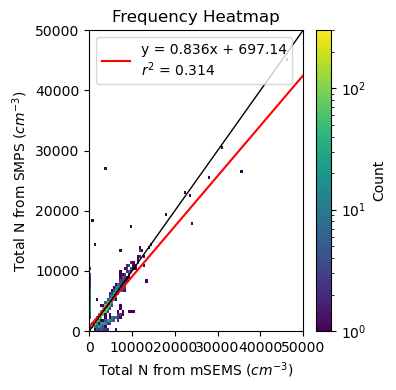

In [108]:
x = miniaomsems_total_N_resampled.values
y = aossmps_total_N_resampled.values
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]

plot_linear_regression(x, y, x_label="Total N from mSEMS", y_label="Total N from SMPS", xlim=[0, 50000], ylim=[0, 50000],
                      bins=100)

In [42]:
aossmps_total_N_resampled

<xarray.Dataset> Size: 263kB
Dimensions:                   (time: 3659)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2025-11-14T23:00:00 ...
Data variables:
    total_N_conc              (time) float32 15kB 2.425e+03 ... 4.288e+03
    flow_rate                 (time) float32 15kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    sample_relative_humidity  (time) float32 15kB 18.49 18.73 ... 20.44 20.47
    sample_temperature        (time) float32 15kB 23.41 23.47 ... 23.23 23.35
    status                    (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    flag_flow                 (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    flag_rh                   (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    flag_status               (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    flag_conc_range           (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    any_flag                  (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0

As with the OPC–APS comparison, we examine whether the mSEMS–SMPS bias is stable across the deployment period by computing the linear regression slope, intercept, and $r^2$ month by month.

In [ ]:
months = [11, 12, 1, 2, 3, 4]
time_strings = ["2024-11", "2024-12", "2025-01", "2025-02", "2025-03", "2025-04"]
slope = np.zeros(len(months))
intercept = np.zeros(len(months))
r = np.zeros(len(months))

for i, t in enumerate(months):
    x = miniaomsems_total_N_resampled.isel(time=miniaomsems_total_N_resampled.time.dt.month == t).values
    y = aossmps_total_N_resampled.isel(time=aossmps_total_N_resampled.time.dt.month == t).values
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) > 1:
        slope[i], intercept[i], r[i], *_ = stats.linregress(x, y)

times = np.array(time_strings, dtype="datetime64")
fig, ax = plt.subplots(3, 1, figsize=(6, 8))
ax[0].plot(times, slope, marker='o')
ax[0].set_ylabel("Slope")
ax[1].plot(times, intercept, marker='o')
ax[1].set_ylabel("Intercept ($cm^{-3}$)")
ax[2].plot(times, r**2, marker='o')
ax[2].set_ylabel("$R^{2}$")
ax[2].set_xlabel("Month [YYYY-MM]")
ax[0].set_title("Linear regression parameters by month: $N$ mSEMS vs $N$ SMPS")
plt.tight_layout()
plt.show()

Now we split the mSEMS–SMPS comparison into the same four time periods used for the OPC–APS analysis to allow direct seasonal comparison between the two instrument pairs.

406 points in X, 406 points in Y between 2025-11-01 and 2025-12-01
1298 points in X, 1298 points in Y between 2025-12-01 and 2026-02-01
779 points in X, 779 points in Y between 2026-02-01 and 2026-04-01
610 points in X, 610 points in Y between 2026-04-01 and 2026-05-01


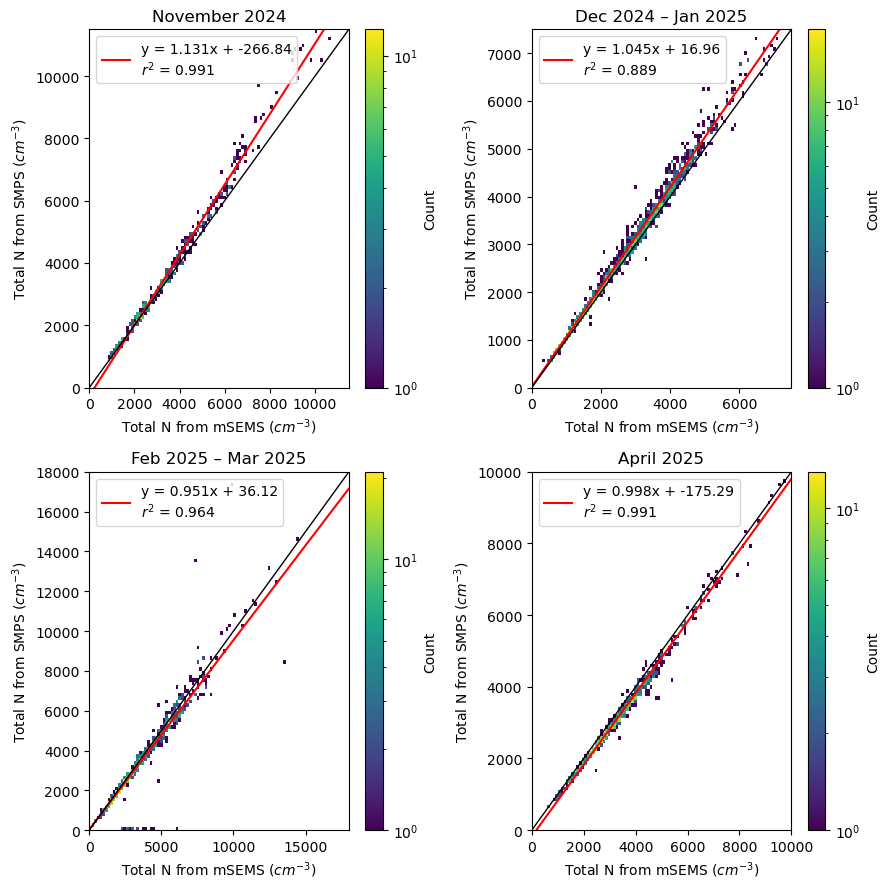

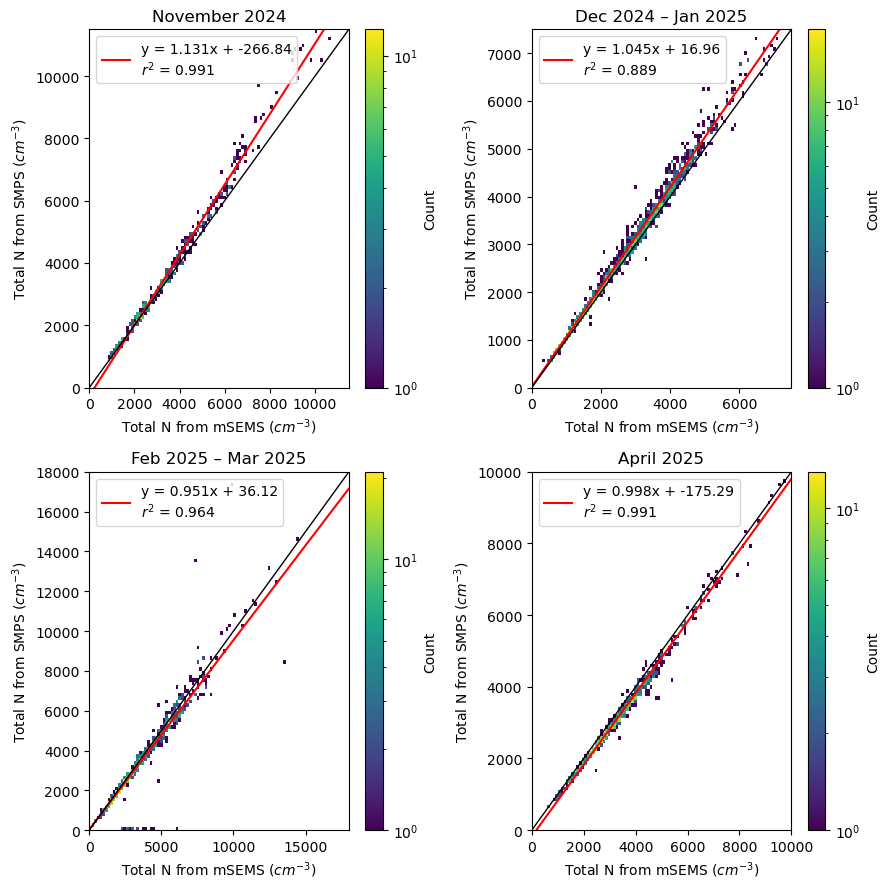

In [37]:
plot_seasonal_panels(miniaomsems_total_N_resampled["total_N_conc"], 
                     aossmps_total_N_resampled["total_N_conc"],
                     x_label="Total N from mSEMS", y_label="Total N from SMPS", bins=100)

The above plots show a disturbing bifurcation occurring during Dec-Jan 2025. Let's see what time periods when mSEMS > 2*SMPS.

(0.0, 5.0)

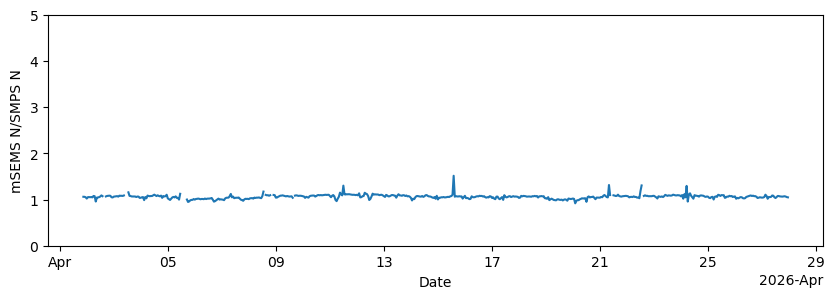

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ratio = miniaomsems_total_N_resampled/aossmps_total_N_resampled
ratio["total_N_conc"].sel(time=slice('2026-04-01T00:00:00', '2026-04-30T23:59:00')).plot()
plt.xlabel('Date')
plt.ylabel('mSEMS N/SMPS N')
plt.savefig('ratio_plotApr_mSEMS_SMPS.png', bbox_inches='tight')
plt.ylim([0, 5])

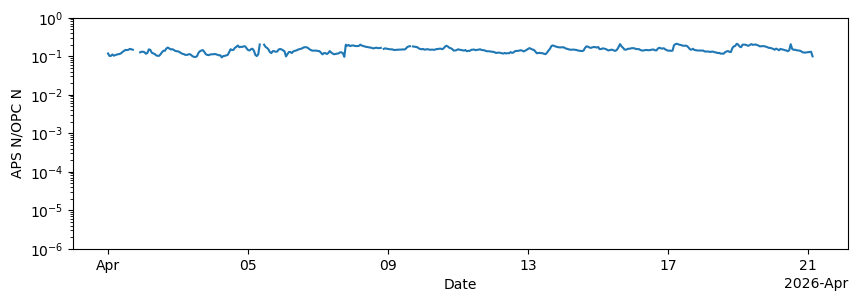

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ratio = aosaps_total_N_resampled/miniaosopc_total_N_resampled
ratio["total_N_conc"].sel(time=slice('2026-04-01T00:00:00', '2026-04-30T23:59:00')).plot()
plt.xlabel('Date')
plt.ylabel('APS N/OPC N')
plt.yscale('log')
plt.ylim([1e-6, 1])
plt.savefig('ratio_plotNov_APSOPC.png', bbox_inches='tight')

In [67]:
msems_smps_flag_pair = compare_instrument_pair(aossmps_total_N_resampled,
                                               miniaomsems_total_N_resampled,
                                               "smps", "msems")
msems_smps_flag_pair 

<xarray.Dataset> Size: 88kB
Dimensions:       (time: 3659)
Coordinates:
  * time          (time) datetime64[ns] 29kB 2025-11-14T23:00:00 ... 2026-04-...
Data variables:
    n_smps        (time) float32 15kB 2.425e+03 2.587e+03 ... 4.288e+03
    n_msems       (time) float32 15kB 2.448e+03 2.59e+03 ... 3.855e+03 4.49e+03
    bias_pct      (time) float32 15kB 0.9528 0.1248 -4.703 ... 6.445 5.25 4.713
    flag_zero     (time) bool 4kB False False False False ... False False False
    flag_missing  (time) bool 4kB False False False False ... False False False
    flag_outlier  (time) bool 4kB False False True False ... False False False
    any_flag      (time) bool 4kB False False True False ... False False False

In [117]:
aossmps_total_N_resampled

<xarray.Dataset> Size: 135kB
Dimensions:                   (time: 3659)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2025-11-14T23:00:00 ...
Data variables:
    total_N_conc              (time) float32 15kB 2.425e+03 ... 4.288e+03
    flow_rate                 (time) float32 15kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    sample_relative_humidity  (time) float32 15kB 18.49 18.73 ... 20.44 20.47
    sample_temperature        (time) float32 15kB 23.41 23.47 ... 23.23 23.35
    status                    (time) int64 29kB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    flag_flow                 (time) bool 4kB False False False ... False False
    flag_rh                   (time) bool 4kB False False False ... False False
    flag_status               (time) bool 4kB True True True ... True True True
    flag_conc_range           (time) bool 4kB False False False ... False False
    any_flag                  (time) bool 4kB True True True ... True True True

In [68]:
## Plot time-height curtain of flags
_PRETTY_TICK_NAMES = {
    "flag_conc_range": "Outside usual concentration",
    "flag_status": "Instrument error code thrown",
    "flag_rh": "Sample RH outside of range",
    "flag_flow": "Sample flow out of range",
    "flag_zero": "Conc < 5/cc",
    "flag_missing": "Incomplete pair",
    "flag_outlier": "Statistical outlier",
    "flag_rain": "Rain",
    "flag_fog": "Fog",
    "flag_temp": "Sample temperature out of range."
    }

def plot_flags_curtain(dataset, start_time, end_time, ax=None, apsopc=True):
    sliced_dataset = dataset.sel(time=slice(start_time, end_time))
    flag_list = []
    for var in sliced_dataset.variables:
        if "flag_" in var:
            if var == "flag_zero" and apsopc is True:
                continue
            flag_list.append(var)
    flag_matrix = np.zeros((sliced_dataset.sizes["time"], len(flag_list)))
    flag_names = []
    for i, flag in enumerate(flag_list):
        flag_matrix[:, i] = sliced_dataset[flag]

    flag_matrix = xr.DataArray(flag_matrix, dims=['time', 'flag_no'], coords={'time': sliced_dataset["time"]})
    print(sliced_dataset)
    if ax is None:
        ax = plt.gca()
    flag_matrix.T.plot(vmin=0, vmax=1, cmap='Greys', cbar_kwargs=dict(ticks=[0,1]))
    
    ax.set_yticks(range(0, len(flag_list)))
    ax.set_ylabel("Flag")
    ax.set_xlabel("Date")
    tick_labels = [_PRETTY_TICK_NAMES[x] for x in flag_list]
    ax.set_yticklabels(tick_labels)
    
    return ax                  
    

In [ ]:
pairs = [('2025-11-01T00:00:00', '2025-11-30T23:59:00'),
         ('2025-12-01T00:00:00', '2025-12-31T23:59:00'),
         ('2026-01-01T00:00:00', '2026-01-31T23:59:00'),
         ('2026-02-01T00:00:00', '2026-02-28T23:59:00'),
         ('2026-03-01T00:00:00', '2026-03-31T23:59:00'),
         ('2026-04-01T00:00:00', '2026-04-30T23:59:00')]
for p in pairs:
    fig = plt.figure(figsize=(10, 3))
    ax = plt.axes()
    plot_flags_curtain(miniaomsems_total_N_resampled, p[0], p[1], ax=ax)
    month = p[0].split("-")[1]
    year = p[0].split("-")[0]
    ax.set_title(f"Flags mSEMS {month}-{year}")
    fig.savefig(f'single_instrument_flags/Flags{year}.{month}.msems.png', bbox_inches='tight')
    plt.close(fig)
    fig = plt.figure(figsize=(10, 3))
    ax = plt.axes()
    plot_flags_curtain(aossmps_total_N_resampled, p[0], p[1], ax=ax)
    month = p[0].split("-")[1]
    fig.savefig(f'single_instrument_flags/Flags{year}.{month}.SMPS.png', bbox_inches='tight')
    ax.set_title(f"Flags SMPS {month}-{year}")
    plt.close(fig)
    fig = plt.figure(figsize=(10, 3))
    ax = plt.axes()
    plot_flags_curtain(aosaps_total_N_resampled, p[0], p[1], ax=ax)
    month = p[0].split("-")[1]
    fig.savefig(f'single_instrument_flags/Flags{year}.{month}.APS.png', bbox_inches='tight')
    ax.set_title(f"Flags APS {month}-{year}")
    plt.close(fig)
    fig = plt.figure(figsize=(10, 3))
    ax = plt.axes()
    plot_flags_curtain(miniaosopc_total_N_resampled, p[0], p[1], ax=ax)
    month = p[0].split("-")[1]
    fig.savefig(f'single_instrument_flags/Flags{year}.{month}.OPC.png', bbox_inches='tight')
    ax.set_title(f"Flags OPC {month}-{year}")
    plt.close(fig)
    fig = plt.figure(figsize=(10, 3))
    ax = plt.axes()
    plot_flags_curtain(miniaosopc_total_N_resampled, p[0], p[1], ax=ax)
    month = p[0].split("-")[1]
    fig.savefig(f'single_instrument_flags/Flags{year}.{month}.OPC.png', bbox_inches='tight')
    ax.set_title(f"Flags OPC {month}-{year}")
    plt.close(fig)
    fig = plt.figure(figsize=(10, 3))
    ax = plt.axes()
    plot_flags_curtain(aps_opc_flags, p[0], p[1], ax=ax, apsopc=True)
    month = p[0].split("-")[1]
    ax.set_title(f"Flags APS-OPC paired {month}-{year}")
    fig.savefig(f'single_instrument_flags/Flags{year}.{month}.APS-OPC.png', bbox_inches='tight')
    plt.close(fig)
    fig = plt.figure(figsize=(10, 3))
    ax = plt.axes()
    plot_flags_curtain(msems_smps_flag_pair, p[0], p[1], ax=ax, apsopc=False)
    month = p[0].split("-")[1]
    ax.set_title(f"Flags mSEMS-SMPS paired {month}-{year}")
    fig.savefig(f'single_instrument_flags/Flags{year}.{month}.mSEMS-SMPS.png', bbox_inches='tight')
    plt.close(fig)

# Create plots of the bias as a function of T, rh, and wind speed

Here, we will look at how the bias varies with T, rh, and wind speed by using box-whisker plots. We will divide the temperature, relative humidity, and wind speed into 5 equal size intervals. 

In [62]:
met_vars

(<xarray.Dataset> Size: 81kB
 Dimensions:       (time: 3392)
 Coordinates:
   * time          (time) datetime64[ns] 27kB 2025-11-15 ... 2026-04-29T23:00:00
 Data variables:
     rh_mean       (time) float32 14kB 62.12 65.97 65.86 ... 73.36 76.07 81.23
     precip_accum  (time) float32 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
     temp_mean     (time) float32 14kB 18.3 17.6 16.8 16.6 ... 24.8 23.0 21.4
     wind_speed    (time) float32 14kB 0.7853 0.7673 0.9806 ... 0.6278 0.5755,
 <xarray.Dataset> Size: 81kB
 Dimensions:       (time: 3392)
 Coordinates:
   * time          (time) datetime64[ns] 27kB 2025-11-15 ... 2026-04-29T23:00:00
 Data variables:
     n_aps         (time) float32 14kB 101.2 116.9 136.2 ... 90.73 75.17 63.71
     n_opc         (time) float32 14kB 9.935 11.15 13.04 ... 0.5482 0.4936 0.401
     bias_pct      (time) float32 14kB -90.19 -90.46 -90.43 ... -99.34 -99.37
     flag_zero     (time) bool 3kB False False False False ... True True True
     flag_missing  (tim

In [36]:
ratio_msems_smps = miniaomsems_total_N_resampled/aossmps_total_N_resampled
ratio_aps_opc = aosaps_total_N_resampled/miniaosopc_total_N_resampled
combined_met_ratio_data = xr.Dataset({'ratio_msems_smps': ratio_msems_smps["total_N_conc"],
                                      'ratio_aps_opc': ratio_aps_opc["total_N_conc"],
                                      'rh_mean': met_vars[0]['rh_mean'],
                                      'precip_accum': met_vars[0]['precip_accum'],
                                      'temp_mean': met_vars[0]['temp_mean'],
                                      'wind_speed': met_vars[0]['wind_speed'],
                                      'total_N_conc_smps': aossmps_total_N_resampled["total_N_conc"]})

In [35]:
aossmps_total_N_resampled

<xarray.Dataset> Size: 263kB
Dimensions:                   (time: 3659)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2025-11-14T23:00:00 ...
Data variables:
    total_N_conc              (time) float32 15kB 2.425e+03 ... 4.288e+03
    flow_rate                 (time) float32 15kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    sample_relative_humidity  (time) float32 15kB 18.49 18.73 ... 20.44 20.47
    sample_temperature        (time) float32 15kB 23.41 23.47 ... 23.23 23.35
    status                    (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    flag_flow                 (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    flag_rh                   (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    flag_status               (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    flag_conc_range           (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    any_flag                  (time) float64 29kB 0.0 0.0 0.0 ... 0.0 0.0 0.0

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/var/folders/f7/j8d4tzw924s73dlkdx4d4h_c0000gp/T/ipykernel_4746/393861259.py:23: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel("Temperature [$^{\circ}C$]")


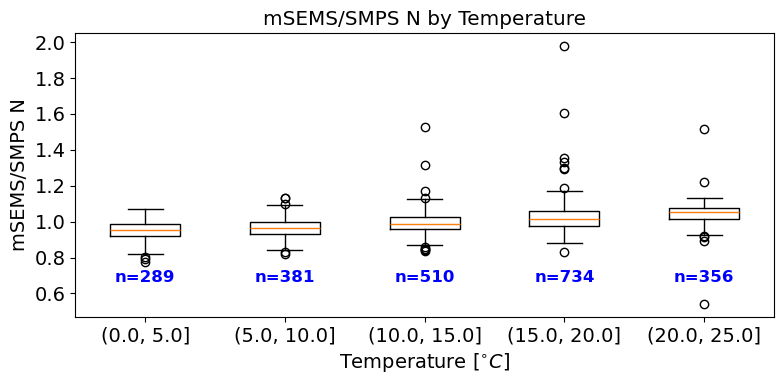

In [27]:
ratio_msems_smps_groupby_t = combined_met_ratio_data["ratio_msems_smps"].groupby_bins(
    combined_met_ratio_data['temp_mean'], np.arange(0, 30, 5.))
# build (label, values) pairs, dropping NaNs per group
labels, data = [], []
counts = []
for label, grp in ratio_msems_smps_groupby_t :
    vals = grp.values.ravel()
    vals = vals[np.isfinite(vals)]
    labels.append(label)
    data.append(vals)
    counts.append(len(vals))

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(data, tick_labels=labels, showfliers=True)
plt.rcParams.update({'font.size': 12})
for i in range(len(counts)):
    median_y = bp['medians'][i].get_ydata()[0]
    n = counts[i]
    # Place text above the median (x-position is 1-indexed for boxplots)
    ax.text(i + 1, 0.65, f'n={n}', 
                ha='center', va='bottom', fontweight='bold', color='blue')

ax.set_xlabel("Temperature [$^{\circ}C$]")
ax.set_ylabel("mSEMS/SMPS N")
ax.set_title(f"mSEMS/SMPS N by Temperature")
fig.tight_layout()
fig.savefig('msems_smps_by_temperature.png', dpi=150, bbox_inches='tight')

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/var/folders/f7/j8d4tzw924s73dlkdx4d4h_c0000gp/T/ipykernel_4746/2296520628.py:23: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel("Temperature [$^{\circ}C$]")


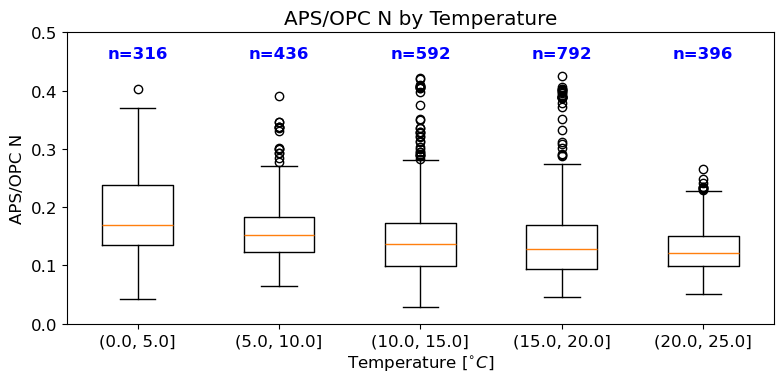

In [28]:
ratio_aps_opc_groupby_t = combined_met_ratio_data["ratio_aps_opc"].groupby_bins(
    combined_met_ratio_data['temp_mean'], np.arange(0, 30, 5.))
# build (label, values) pairs, dropping NaNs per group
labels, data = [], []
counts = []
for label, grp in ratio_aps_opc_groupby_t:
    vals = grp.values.ravel()
    vals = vals[np.isfinite(vals)]
    labels.append(label)
    data.append(vals)
    counts.append(len(vals))


fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(data, tick_labels=labels, showfliers=True)
for i in range(len(counts)):
    median_y = bp['medians'][i].get_ydata()[0]
    n = counts[i]
    # Place text above the median (x-position is 1-indexed for boxplots)
    ax.text(i + 1, 0.45, f'n={n}', 
                ha='center', va='bottom', fontweight='bold', color='blue')
    
ax.set_xlabel("Temperature [$^{\circ}C$]")
ax.set_ylabel("APS/OPC N")
ax.set_title(f"APS/OPC N by Temperature")
ax.set_ylim([0, 0.5])
fig.tight_layout()
fig.savefig('aps_opc_by_temperature.png', dpi=150, bbox_inches='tight')

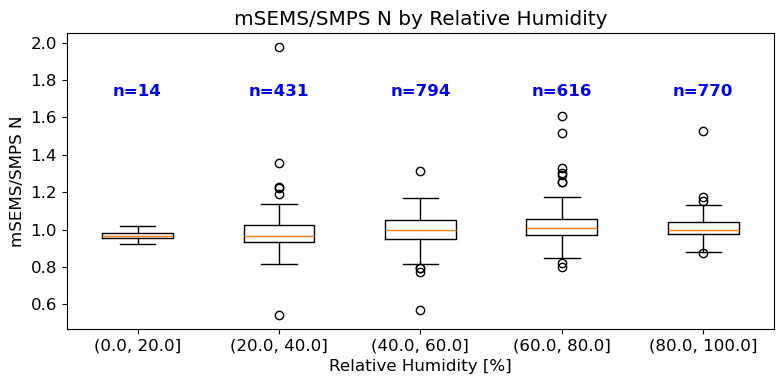

In [29]:
ratio_msems_smps_groupby_t = combined_met_ratio_data["ratio_msems_smps"].groupby_bins(
    combined_met_ratio_data['rh_mean'], np.arange(0, 101, 20.))
# build (label, values) pairs, dropping NaNs per group
labels, data = [], []
counts = []
for label, grp in ratio_msems_smps_groupby_t :
    vals = grp.values.ravel()
    vals = vals[np.isfinite(vals)]
    labels.append(label)
    data.append(vals)
    counts.append(len(vals))
    
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(data, tick_labels=labels, showfliers=True)
for i in range(len(counts)):
    median_y = bp['medians'][i].get_ydata()[0]
    n = counts[i]
    # Place text above the median (x-position is 1-indexed for boxplots)
    ax.text(i + 1, 1.7, f'n={n}', 
                ha='center', va='bottom', fontweight='bold', color='blue')
    
ax.set_xlabel("Relative Humidity [%]")
ax.set_ylabel("mSEMS/SMPS N")
ax.set_title(f"mSEMS/SMPS N by Relative Humidity")
fig.tight_layout()
fig.savefig('msems_smps_by_rh.png', dpi=150, bbox_inches='tight')

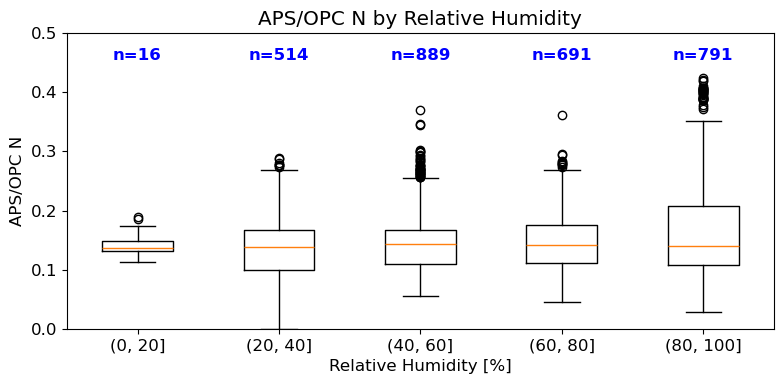

In [30]:
ratio_aps_opc_groupby_t = combined_met_ratio_data["ratio_aps_opc"].groupby_bins(
    combined_met_ratio_data['rh_mean'], np.arange(0, 101, 20))
# build (label, values) pairs, dropping NaNs per group
labels, data = [], []
counts = []
for label, grp in ratio_aps_opc_groupby_t:
    vals = grp.values.ravel()
    vals = vals[np.isfinite(vals)]
    labels.append(label)
    data.append(vals)
    counts.append(len(vals))

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(data, tick_labels=labels, showfliers=True)
for i in range(len(counts)):
    median_y = bp['medians'][i].get_ydata()[0]
    n = counts[i]
    # Place text above the median (x-position is 1-indexed for boxplots)
    ax.text(i + 1, 0.45, f'n={n}', 
                ha='center', va='bottom', fontweight='bold', color='blue')
ax.set_xlabel("Relative Humidity [%]")
ax.set_ylabel("APS/OPC N")
ax.set_title(f"APS/OPC N by Relative Humidity")
ax.set_ylim([0, 0.5])
fig.tight_layout()
fig.savefig('aps_opc_by_rh.png', dpi=150, bbox_inches='tight')

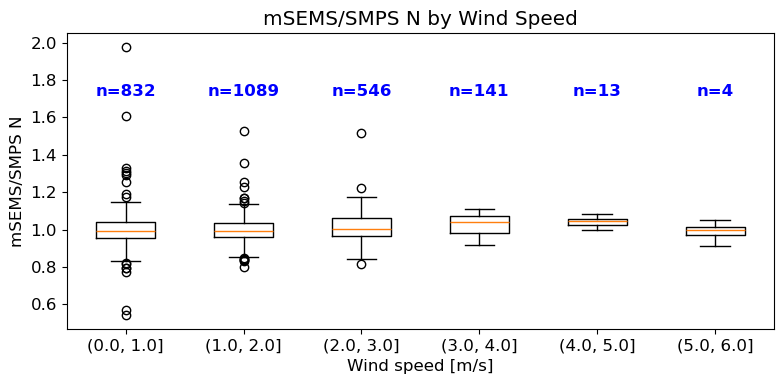

In [31]:
ratio_msems_smps_groupby_t = combined_met_ratio_data["ratio_msems_smps"].groupby_bins(
    combined_met_ratio_data['wind_speed'], np.arange(0, 7, 1.))
# build (label, values) pairs, dropping NaNs per group
labels, data = [], []
counts = []
for label, grp in ratio_msems_smps_groupby_t :
    vals = grp.values.ravel()
    vals = vals[np.isfinite(vals)]
    labels.append(label)
    data.append(vals)
    counts.append(len(vals))
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(data, tick_labels=labels, showfliers=True)
for i in range(len(counts)):
    median_y = bp['medians'][i].get_ydata()[0]
    n = counts[i]
    # Place text above the median (x-position is 1-indexed for boxplots)
    ax.text(i + 1, 1.7, f'n={n}', 
                ha='center', va='bottom', fontweight='bold', color='blue')
ax.set_xlabel("Wind speed [m/s]")
ax.set_ylabel("mSEMS/SMPS N")
ax.set_title(f"mSEMS/SMPS N by Wind Speed")
fig.tight_layout()
fig.savefig('msems_smps_by_wind_speed.png', dpi=150, bbox_inches='tight')

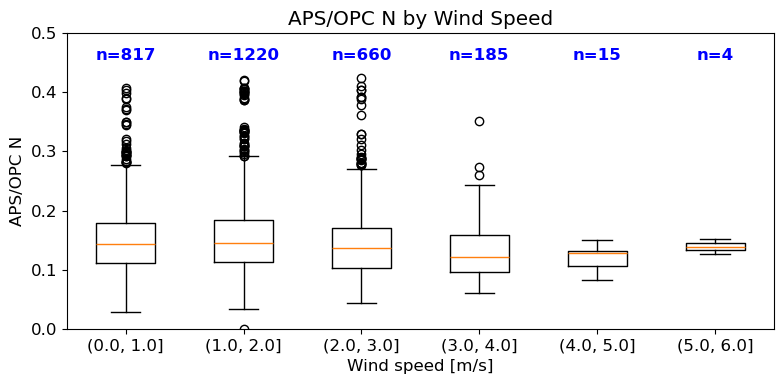

In [32]:
ratio_msems_smps_groupby_t = combined_met_ratio_data["ratio_aps_opc"].groupby_bins(
    combined_met_ratio_data['wind_speed'], np.arange(0, 10, 1.))
# build (label, values) pairs, dropping NaNs per group
labels, data, counts = [], [], []
for label, grp in ratio_msems_smps_groupby_t :
   vals = grp.values.ravel()
   vals = vals[np.isfinite(vals)]
   labels.append(label)
   data.append(vals)
   counts.append(len(vals))
                 
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(data, tick_labels=labels, showfliers=True)
for i in range(len(counts)):
    median_y = bp['medians'][i].get_ydata()[0]
    n = counts[i]
    # Place text above the median (x-position is 1-indexed for boxplots)
    ax.text(i + 1, 0.45, f'n={n}', 
                ha='center', va='bottom', fontweight='bold', color='blue')
ax.set_xlabel("Wind speed [m/s]")
ax.set_ylabel("APS/OPC N")
ax.set_title(f"APS/OPC N by Wind Speed")
ax.set_ylim([0, 0.5])
fig.tight_layout()
fig.savefig('aps_opc_by_wind_speed.png', dpi=150, bbox_inches='tight')

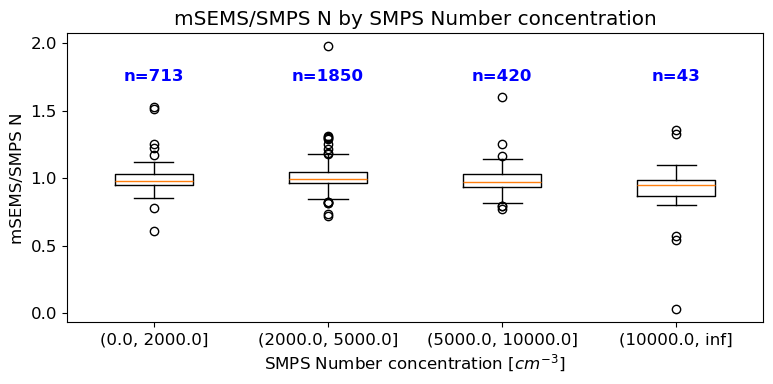

In [39]:
ratio_msems_smps_groupby_t = combined_met_ratio_data["ratio_msems_smps"].groupby_bins(
    combined_met_ratio_data["total_N_conc_smps"], np.array([0, 2000, 5000, 10000, np.inf]))
# build (label, values) pairs, dropping NaNs per group
labels, data = [], []
counts = []
for label, grp in ratio_msems_smps_groupby_t :
    vals = grp.values.ravel()
    vals = vals[np.isfinite(vals)]
    labels.append(label)
    data.append(vals)
    counts.append(len(vals))
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(data, tick_labels=labels, showfliers=True)
for i in range(len(counts)):
    median_y = bp['medians'][i].get_ydata()[0]
    n = counts[i]
    # Place text above the median (x-position is 1-indexed for boxplots)
    ax.text(i + 1, 1.7, f'n={n}', 
                ha='center', va='bottom', fontweight='bold', color='blue')
ax.set_xlabel("SMPS Number concentration [$cm^{-3}$]")
ax.set_ylabel("mSEMS/SMPS N")
ax.set_title(f"mSEMS/SMPS N by SMPS Number concentration")
fig.tight_layout()
fig.savefig('msems_smps_by_wind_speed.png', dpi=150, bbox_inches='tight')

In [70]:
combined_met_ratio_data["temp_mean"].quantile(0.25)

<xarray.DataArray 'temp_mean' ()> Size: 8B
array(6.9000001)
Coordinates:
    quantile  float64 8B 0.25

---

## Summary

This notebook characterizes the bias in total particle number concentration between the ARM AOS and miniAOS instrument suites deployed at the Bankhead National Forest (BNF) AMF3 site from November 2024 through April 2025.

Two instrument pairs were compared:

1. **OPC (miniAOS) vs. APS (AOS)** — optical vs. aerodynamic sizing. A systematic high bias in OPC-derived concentrations is expected due to the difference in sizing principle; the magnitude and stability of this bias is quantified here across four seasonal sub-periods.
2. **mSEMS (miniAOS) vs. SMPS (AOS)** — both use electrical mobility sizing. Agreement is expected to be much closer, with residual differences attributable to calibration offsets or flow rate drift rather than measurement principle.

The seasonal breakdown reveals whether the miniAOS bias is stable over time, which is critical for determining whether a simple correction factor can be applied across the full deployment period.

### What's next?

- Extend this comparison to size-resolved number distributions ($dN/d\log D_p$) rather than integrated total $N$.

## Resources and References

- [ARM Climate Research Facility](https://www.arm.gov)
- [ARM Data Center (ADC)](https://adc.arm.gov/discovery/) — data discovery and download
- [ACT (Atmospheric data Community Toolkit)](https://arm-doe.github.io/ACT/index.html) — ARM data I/O and analysis
- Uin, J., et al. (2019). Atmospheric Radiation Measurement (ARM) Aerosol Observing Systems (AOS) for Surface-Based In Situ Atmospheric Aerosol and Trace Gas Measurements. *Journal of Atmospheric and Oceanic Technology*, 36(12). https://doi.org/10.1175/JTECH-D-19-0077.1
- Singh, A., Kuang, C., et al. Scanning Mobility Particle Sizer (AOSSMPS), Bankhead National Forest, AL. ARM User Facility. https://doi.org/10.5439/1476898
- Singh, A., Oliveira, D., et al. Aerodynamic Particle Sizer (AOSAPS), Bankhead National Forest, AL. ARM User Facility. https://doi.org/10.5439/1407135